# Exploratory data analysis

## Imports

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading data

In [7]:
customers = pd.read_csv('../data/180601_Customer_Info.csv')
customers

,customer_id,sign_up_date,sign_up_channel
0,2543,2021-04-26,Price Comparison Website
1,2181,2021-07-24,Referral
2,2399,2020-10-11,Bulb Website
3,674,2021-04-04,Referral
4,2332,2021-09-05,Price Comparison Website
...,...,...,...
1694,820,2021-07-17,Referral
1695,1945,2020-12-20,Price Comparison Website
1696,2132,2021-11-29,Bulb Website
1697,2228,2021-10-11,Referral


In [8]:
referrals = pd.read_csv('../data/180601_Referrals_Info.csv')
referrals

,referral_date,referrer_customer_id,sign_up_customer_id
0,2021-07-18,795,1771
1,2021-04-12,577,1510
2,2021-07-07,868,1858
3,2021-10-25,801,1778
4,2021-08-15,690,1637
...,...,...,...
995,2021-07-17,812,1789
996,2021-12-15,156,1031
997,2021-07-20,601,1537
998,2021-07-11,440,1350


## Exploration

### Data types

In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_id      1699 non-null   int64
 1   sign_up_date     1699 non-null   str  
 2   sign_up_channel  1699 non-null   str  
dtypes: int64(1), str(2)
memory usage: 39.9 KB


In [25]:
customers['sign_up_date'] = pd.to_datetime(customers['sign_up_date'])
# customers.info()

In [26]:
referrals['referral_date'] = pd.to_datetime(referrals['referral_date'])
# referrals.info()

In [23]:
customers['referrer_customer_id'] = customers['customer_id']

### When do members refer?

In [27]:
referrers = referrals.merge(customers, how='inner', on='referrer_customer_id')
referrers

,referral_date,referrer_customer_id,sign_up_customer_id,customer_id,sign_up_date,sign_up_channel
0,2021-07-18,795,1771,795,2021-03-03,Price Comparison Website
1,2021-04-12,577,1510,577,2021-03-28,Price Comparison Website
2,2021-07-07,868,1858,868,2021-03-07,Bulb Website
3,2021-10-25,801,1778,801,2021-04-30,Referral
4,2021-08-15,690,1637,690,2021-07-29,Price Comparison Website
...,...,...,...,...,...,...
827,2021-07-17,448,1359,448,2021-05-27,Referral
828,2021-07-17,812,1789,812,2021-05-02,Price Comparison Website
829,2021-12-15,156,1031,156,2021-03-02,Bulb Website
830,2021-07-20,601,1537,601,2021-04-18,Bulb Website


#### Computing referrer lifetimes 

In [35]:
referrers['lifetime'] = (referrers['referral_date'] - referrers['sign_up_date']).dt.days
referrers

,referral_date,referrer_customer_id,sign_up_customer_id,customer_id,sign_up_date,sign_up_channel,lifetime
0,2021-07-18,795,1771,795,2021-03-03,Price Comparison Website,137
1,2021-04-12,577,1510,577,2021-03-28,Price Comparison Website,15
2,2021-07-07,868,1858,868,2021-03-07,Bulb Website,122
3,2021-10-25,801,1778,801,2021-04-30,Referral,178
4,2021-08-15,690,1637,690,2021-07-29,Price Comparison Website,17
...,...,...,...,...,...,...,...
827,2021-07-17,448,1359,448,2021-05-27,Referral,51
828,2021-07-17,812,1789,812,2021-05-02,Price Comparison Website,76
829,2021-12-15,156,1031,156,2021-03-02,Bulb Website,288
830,2021-07-20,601,1537,601,2021-04-18,Bulb Website,93


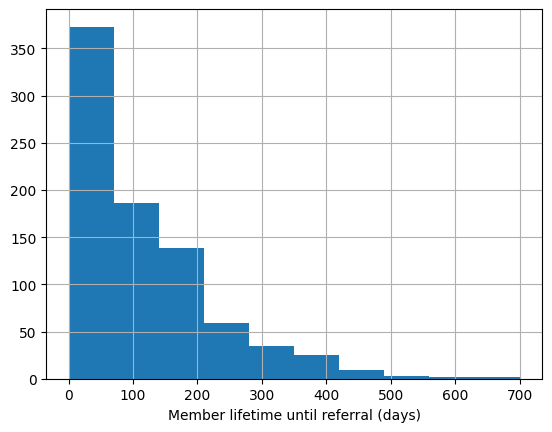

In [46]:
referrers['lifetime'].hist(bins=10)
plt.xlabel('Member lifetime until referral (days)');

In [41]:
referrers['lifetime'].mean()

np.float64(113.65384615384616)

Considering that a lot of members have not been with Bulb for very long, long lifetimes can be considered outliers so the median is a more adequate estimate of when members refer.

In [47]:
print(referrers['lifetime'].median())

83.5


### Does the channel members are acquired from significantly impact how they refer?

In [49]:
referrers

,referral_date,referrer_customer_id,sign_up_customer_id,customer_id,sign_up_date,sign_up_channel,lifetime
0,2021-07-18,795,1771,795,2021-03-03,Price Comparison Website,137
1,2021-04-12,577,1510,577,2021-03-28,Price Comparison Website,15
2,2021-07-07,868,1858,868,2021-03-07,Bulb Website,122
3,2021-10-25,801,1778,801,2021-04-30,Referral,178
4,2021-08-15,690,1637,690,2021-07-29,Price Comparison Website,17
...,...,...,...,...,...,...,...
827,2021-07-17,448,1359,448,2021-05-27,Referral,51
828,2021-07-17,812,1789,812,2021-05-02,Price Comparison Website,76
829,2021-12-15,156,1031,156,2021-03-02,Bulb Website,288
830,2021-07-20,601,1537,601,2021-04-18,Bulb Website,93


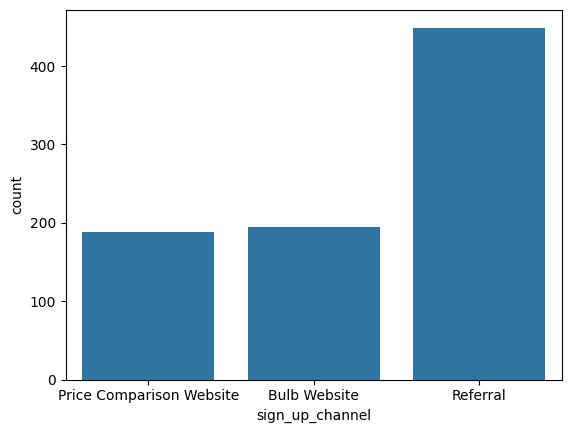

In [51]:
sns.countplot(data=referrers, x='sign_up_channel');

In [56]:
referrers['sign_up_channel'].value_counts(normalize=False)

sign_up_channel
Referral                    449
Bulb Website                195
Price Comparison Website    188
Name: count, dtype: int64

<Axes: xlabel='lifetime', ylabel='sign_up_channel'>

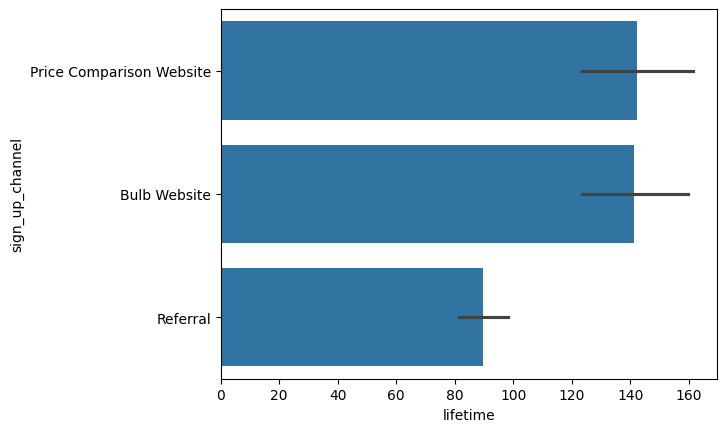

In [55]:
sns.barplot(data=referrers, y='sign_up_channel', x='lifetime')

In [74]:
customers['sign_up_channel'].value_counts()

sign_up_channel
Price Comparison Website    780
Referral                    565
Bulb Website                354
Name: count, dtype: int64

In [76]:
referrers['referrer_customer_id'].value_counts()

referrer_customer_id
8      34
6      11
10      9
36      9
37      8
       ..
448     1
812     1
156     1
601     1
55      1
Name: count, Length: 701, dtype: int64

In [73]:
referrers[referrers['referrer_customer_id']==6]

,referral_date,referrer_customer_id,sign_up_customer_id,customer_id,sign_up_date,sign_up_channel,lifetime
45,2021-07-14,6,1034,6,2020-12-25,Referral,201
115,2021-07-17,6,1588,6,2020-12-25,Referral,204
189,2021-05-05,6,1161,6,2020-12-25,Referral,131
241,2021-03-08,6,1764,6,2020-12-25,Referral,73
410,2021-07-20,6,1100,6,2020-12-25,Referral,207
520,2021-05-31,6,893,6,2020-12-25,Referral,157
598,2021-08-22,6,1410,6,2020-12-25,Referral,240
625,2021-01-17,6,889,6,2020-12-25,Referral,23
689,2021-07-24,6,1414,6,2020-12-25,Referral,211
717,2021-05-05,6,1308,6,2020-12-25,Referral,131


In [86]:
sum(referrers[referrers['sign_up_channel'] == 'Referral']['referrer_customer_id'].value_counts()>1)

28

In [87]:
len(referrers[referrers['sign_up_channel'] == 'Referral'])

449

In [88]:
28/449

0.062360801781737196

Number of customers who entered through referral

In [91]:
sum(customers['sign_up_channel'] == 'Referral')

565

Rate of referred customers who in turn referred other members

In [92]:
449/565

0.7946902654867256

Members who entered through the referral system represent over 50% of the referrers, and they refer almost twice as fast as other members.
But only a factor 2 and the sample size may be too low.

### How to proceed to send an email to members to invite them to refer their friends?

A/B testing.
Separate per channel.
Null hypothesis: no email. H1: email after typically 80 days